# News Articles Categorization

## Overview

 According to Internet Live Stats, in every second, around 9,000 tweets are posted; 3 million emails are sent and more than 90,000 GB of Internet traffic. So, we have a big amount of data in the internet. With such data, it is necessary to classify the data in categories. News contents are one type of data that should be categorized into groups to be easily accessed. News categorization helps users to access news of their interest without wasting time.
 
In this project,  I will apply machine learning algorithms on news collected from CNN News website to construct a model that classify the news into groups.

### Dataset


The dataset of this project from [kaggle](https://www.kaggle.com/c/learn-ai-bbc/data).

* BBC News Train.csv - The file contains a dataset of 1490 BBC News articles that classified into five categories: Business, Tech, Politics, Sport, Entertainment.

**Data Fields:**

   - ArticleId - Article id unique # given to the record.
   - Article - text of the header and article.
   - Category - cateogry of the article (tech, business, sport, entertainment, politics)


**The steps to build the model are:**
1. Data Exploration
2. Text Processing
3. Feature Extraction
4. Modeling
5. Use the Model


In [187]:
# Import libraries

import pandas as pd
import re 

import nltk 
from nltk.tokenize import RegexpTokenizer
from collections import Counter 
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.feature_extraction.text import TfidfVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost 
from sklearn.metrics  import classification_report
from sklearn import metrics
import time



## 1. Data Exploration

In [188]:
# Read the dataset from csv file
df1 = pd.read_csv('BBC_News.csv')
df1.head()

,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...


In [189]:
# Find all category
category = list(df1['labels'].unique())
category

['business', 'entertainment', 'politics', 'sport', 'tech']

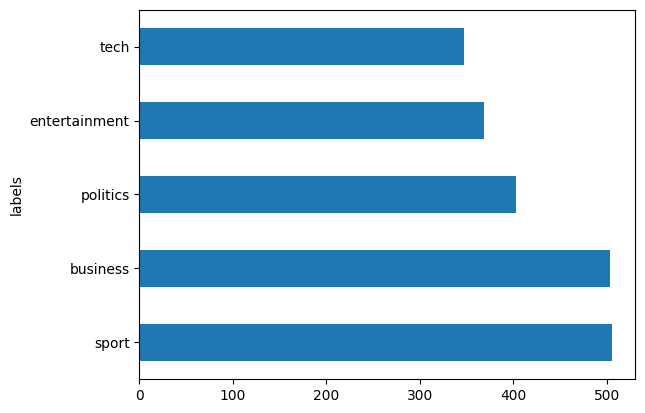

In [190]:
df1['labels'].value_counts().plot(kind='barh')
plt.show()

In [191]:
# Check null values
df1.isnull().sum()

text                            0
labels                          0
no_sentences                    0
Flesch Reading Ease Score       0
Dale-Chall Readability Score    0
text_rank_summary               0
lsa_summary                     0
dtype: int64

## 2. Text Preprocessing

In [192]:
# Text preprocessing
def preprocess(text):
    
    """
    Function: split text into words and return the root form of the words
    Args:
      text(str): the article
    Return:
      lem(list of str): a list of the root form of the article words
    """
        
    # Normalize text
    text = re.sub(r"[^a-zA-Z]", " ", str(text).lower())
    
    # Tokenize text
    token = word_tokenize(text)
    
    # Remove stop words
    stop = stopwords.words("english")
    words = [t for t in token if t not in stop]
    
    # Lemmatization
    lem = [WordNetLemmatizer().lemmatize(w) for w in words]
    
    return lem

In [193]:
df1.head()

,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...


In [194]:
df1.shape

(2127, 7)

In [195]:
df1["Preprocessed_Text"] = df1['text'].apply(lambda x: preprocess(x))
df1.head(10)

,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary,Preprocessed_Text
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...,"[ad, sale, boost, time, warner, profit, quarte..."
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san...","[dollar, gain, greenspan, speech, dollar, hit,..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...,"[yukos, unit, buyer, face, loan, claim, owner,..."
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ...","[high, fuel, price, hit, ba, profit, british, ..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...,"[pernod, takeover, talk, lift, domecq, share, ..."
5,Japan narrowly escapes recession\n\nJapan's ec...,business,13,48.70,10.38,Japan's economy teetered on the brink of a tec...,Revised figures indicated growth of just 0.1% ...,"[japan, narrowly, escape, recession, japan, ec..."
6,Jobs growth still slow in the US\n\nThe US cre...,business,15,60.95,9.06,The US created fewer jobs than expected in Jan...,"According to Labor Department figures, US firm...","[job, growth, still, slow, u, u, created, fewe..."
7,"India calls for fair trade rules\n\nIndia, whi...",business,16,59.53,9.11,"In London on Thursday ahead of the meeting, In...","India, which attends the G7 meeting of seven l...","[india, call, fair, trade, rule, india, attend..."
8,Ethiopia's crop production up 24%\n\nEthiopia ...,business,15,54.83,10.31,Ethiopia produced 14.27 million tonnes of crop...,"Good rains, increased use of fertilizers and i...","[ethiopia, crop, production, ethiopia, produce..."
9,Court rejects $280bn tobacco case\n\nA US gove...,business,10,48.64,11.28,A US government claim accusing the country's b...,A US government claim accusing the country's b...,"[court, reject, bn, tobacco, case, u, governme..."


## 2.1. Text Exploration

In [196]:
# Find the common words in each category
def find_common_words(df, category):
        
    """
    Function: find the most frequent words in the category and return the them
    Args:
      df(dataframe): the dataframe of articles
      category(str): the category name
    Return:
      the most frequant words in the category
    """
        
    # Create dataframes for the category
    cat_df = df[df["labels"]==category]
    
    # Initialize words list for the category
    words = [word for tokens in cat_df["Preprocessed_Text"] for word in tokens]
    
    # Count words frequency
    words_counter = Counter(words)
 
    return words_counter.most_common(10)

In [197]:
print("Most common words in each category")
for c in category:
    print(c, " News")
    print(find_common_words(df1, c))
    print()

Most common words in each category
business  News
[('said', 1655), ('year', 943), ('u', 805), ('bn', 782), ('company', 624), ('mr', 599), ('firm', 533), ('market', 521), ('would', 460), ('also', 432)]

entertainment  News
[('film', 926), ('said', 803), ('year', 653), ('best', 589), ('award', 507), ('music', 423), ('u', 396), ('show', 395), ('also', 382), ('one', 372)]

politics  News
[('said', 2174), ('mr', 1646), ('would', 1008), ('labour', 735), ('government', 728), ('party', 691), ('election', 636), ('people', 607), ('minister', 544), ('blair', 542)]

sport  News
[('said', 930), ('year', 668), ('game', 646), ('time', 481), ('first', 479), ('player', 474), ('win', 466), ('england', 459), ('back', 398), ('would', 396)]

tech  News
[('said', 1368), ('people', 829), ('game', 705), ('technology', 546), ('mobile', 535), ('one', 489), ('phone', 486), ('year', 466), ('also', 460), ('mr', 452)]



In [198]:
df1['Preprocessed_Text2'] = df1['Preprocessed_Text'].apply(' '.join)
df1.head()

,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary,Preprocessed_Text,Preprocessed_Text2
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...,"[ad, sale, boost, time, warner, profit, quarte...",ad sale boost time warner profit quarterly pro...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san...","[dollar, gain, greenspan, speech, dollar, hit,...",dollar gain greenspan speech dollar hit highes...
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...,"[yukos, unit, buyer, face, loan, claim, owner,...",yukos unit buyer face loan claim owner embattl...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ...","[high, fuel, price, hit, ba, profit, british, ...",high fuel price hit ba profit british airway b...
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...,"[pernod, takeover, talk, lift, domecq, share, ...",pernod takeover talk lift domecq share uk drin...


In [199]:
# Determine data and target
X = df1['Preprocessed_Text2']


In [201]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(df1['labels'])
df1['labels'] = le.transform(df1['labels'])
y = df1['labels']

In [202]:
y

0       0
1       0
2       0
3       0
4       0
       ..
2122    4
2123    4
2124    4
2125    4
2126    4
Name: labels, Length: 2127, dtype: int64

# 3. Feature Extraction

I will use TF-IDF method to extract the text features.

In [203]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

y_train

1233    2
480     0
1111    2
1303    3
861     1
       ..
1638    3
1095    2
1130    2
1294    3
860     1
Name: labels, Length: 1701, dtype: int64

In [204]:
y_test

282     0
1999    4
1709    3
988     2
2018    4
       ..
305     0
973     2
611     1
2109    4
192     0
Name: labels, Length: 426, dtype: int64

In [205]:
# Use TF-IDF

# If you had millions of articles and wanted to capture semantic similarity (e.g., “king” ≈ “queen” in vector space).
# If your task was semantic search, document clustering, or topic modeling with deeper relationships between words.
# If you’re combining text with other modalities (e.g., embeddings in recommendation systems).

tf_vec = TfidfVectorizer()
X_train = tf_vec.fit_transform(X_train)
X_test = tf_vec.transform(X_test)

In [206]:
# # SVM
# from sklearn.metrics import classification_report, f1_score, recall_score, accuracy_score, precision_score
# from sklearn import svm

# model = svm.SVC()
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)


# print(accuracy_score(y_test, y_pred))
# print(f1_score(y_test, y_pred, average = 'macro'))
# print(precision_score(y_test, y_pred, average = 'macro'))
# print(recall_score(y_test, y_pred, average = 'macro'))

In [207]:
# print(le.classes_)

In [208]:
# with open('Articles/art1.txt', 'r') as file:
#     article = file.read()

# article = preprocess(article)
# article = ' '.join(article)

# article = tf_vec.transform([article])
# y_pred_new_test = model.predict(article)

# decoded_labels = le.inverse_transform(y_pred_new_test)
# print(decoded_labels)

# 4. Modeling

Here, I will use the below machine learning algorithms then I will select the best one based on its training time, accuracy score and f-beta scores. 

* Support Vector Machine 
* Ada Boost
* Gradient Boosting
* XG Boost
* Decision Tree
* Multinomial Naive Bayes 

In [209]:
# Train and evaluate model

from sklearn.metrics import classification_report, f1_score, recall_score, accuracy_score, precision_score
from sklearn import svm
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
import xgboost

# -------------------------------
# Function: Train and evaluate a model
# ----------------------

def fit_eval_model(model, X_train, y_train, X_test, y_test):
    """
    Trains the given ML model and returns evaluation metrics.

    Args:
        model: The ML model to train
        X_train: TF-IDF vectorized training features
        y_train: Encoded training labels
        X_test: TF-IDF vectorized test features
        y_test: Encoded test labels

    Returns:
        dict: Dictionary containing training time and performance metrics
    """
    results = {}

    # Measure training time
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    results['train_time'] = end - start

    # Predict on test data
    y_pred = model.predict(X_test)

    # Evaluation metrics
    results['classification_report'] = classification_report(y_test, y_pred)
    results['accuracy'] = accuracy_score(y_test, y_pred)
    results['f1_score'] = f1_score(y_test, y_pred, average='macro')
    results['precision'] = precision_score(y_test, y_pred, average='macro')
    results['recall'] = recall_score(y_test, y_pred, average='macro')

    return results

# -------------------------------
# Initialize models
# -------------------------------

models = [
    svm.SVC(),
    AdaBoostClassifier(random_state=1),
    GradientBoostingClassifier(random_state=1),
    xgboost.XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='mlogloss'),
    DecisionTreeClassifier(),
    MultinomialNB()
]

# -------------------------------
# Train & evaluate all models
# -------------------------------

results = {}

for model in models:
    name = model.__class__.__name__
    print(f"Training and evaluating: {name}")
    results[name] = fit_eval_model(model, train_features, y_train, test_features, y_test)
    

Training and evaluating: SVC
Training and evaluating: AdaBoostClassifier
Training and evaluating: GradientBoostingClassifier
Training and evaluating: XGBClassifier


/Users/menapranavkumar/Desktop/VSCode_DS2/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [10:07:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training and evaluating: DecisionTreeClassifier
Training and evaluating: MultinomialNB


In [210]:
# Print classifiers results
for res in results:
    print (res)
    print()
    for i in results[res]:
        print (i, ':')
        print(results[res][i])
        print()
    print ('-----')
    print()

SVC

train_time :
5.171469211578369

classification_report :
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       104
           1       0.99      0.96      0.97        78
           2       0.99      1.00      0.99        73
           3       1.00      1.00      1.00        98
           4       0.96      0.97      0.97        73

    accuracy                           0.98       426
   macro avg       0.98      0.98      0.98       426
weighted avg       0.98      0.98      0.98       426


accuracy :
0.9812206572769953

f1_score :
0.9808726987298415

precision :
0.98078837947259

recall :
0.981059009483667

-----

AdaBoostClassifier

train_time :
1.4884881973266602

classification_report :
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       104
           1       0.88      0.85      0.86        78
           2       0.81      0.92      0.86        73
           3       0.95     

**Note:** From the testing results, we can see that **MultinomialNB** classifier is the fastest and most accurate classifier.

# 5. Use the Model

Now, I will use the built MultinomialNB model to classify new articles. The articles files inside *Articles folder* and here are the articles sources.  

* art1: https://edition.cnn.com/2019/09/30/sport/irish-national-stud-winning-post-spt-intl/index.html
* art2: https://edition.cnn.com/2020/04/15/tech/amazon-france-suspension/index.html
* art3: https://edition.cnn.com/2020/04/15/politics/barack-obama-2020-test/index.html
* art4: https://edition.cnn.com/2020/04/15/entertainment/disney-the-mandalorian-documentary/index.html


In [216]:
# Classify an article

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
def classify_article(path):
    
    """
    Function: classify an article.
    Args:
      path: the path of the article 
    Return:
      category (str): the category of the article
    """
    # Read file
    with open(path, 'r') as file:
      artcl = file.read()

    # Text preprocessing
    artcl = preprocess(artcl)
    artcl = ' '.join(artcl)

    # Use TF_IDF
    test = tf_vec.transform([artcl])

    # Use MultinomialNB model to classify the article
    predict = nb.predict(test)
    category = predict[0]
    # Decode label

    return category

AttributeError: 'LabelEncoder' object has no attribute 'classes_'

In [217]:
print(classify_article('art1.txt'))

NotFittedError: This MultinomialNB instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [19]:
print(classify_article('Articles/art2.txt'))

business


In [20]:
print(classify_article('Articles/art3.txt'))

politics


In [21]:
print(classify_article('Articles/art4.txt'))

entertainment


**Note:** All articles classified correctly.  

# 6. Summary 

In this project, I used CNN news dataset to classify the news text. I used TF-IDF feature extraction algorithm and six different machine learning algorithms: Support Vector Machine , Ada Boost, Gradient Boosting, XG Boost, Decision Tree, Multinomial Naive Bayes. Multinomial Naive Bayes was the best model and then I use it to classify new articles in order to check the model accuracy. 